In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Fluctuator, Trajectory, PGA
from joblib import Parallel, delayed
import joblib
from matplotlib.patches import Ellipse

In [2]:
# check cores
import multiprocessing
print(multiprocessing.cpu_count())

16


In [3]:
file = r'C:\Users\jacob\OneDrive - Danmarks Tekniske Universitet\UNI\6 semester\Bachelor\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
(wind := WindField(profile='rans', ds=file, U_ref=6.0))

WindField(profile=rans) 
Size: 24MB
Dimensions:  (x: 65, y: 65, z: 100)
Coordinates:
  * x        (x) float64 520B -128.0 -124.0 -120.0 -116.0 ... 120.0 124.0 128.0
  * y        (y) float64 520B -128.0 -124.0 -120.0 -116.0 ... 120.0 124.0 128.0
  * z        (z) float64 800B 0.1 0.1072 0.115 0.1233 ... 86.97 93.26 100.0
Data variables:
    U        (x, y, z) float64 3MB 1.403 1.462 1.525 1.593 ... 8.233 8.304 8.375
    V        (x, y, z) float64 3MB -4.175e-06 -4.349e-06 ... 8.259e-06 8.379e-06
    W        (x, y, z) float64 3MB -3.501e-09 -3.878e-09 ... -9.874e-05
    P        (x, y, z) float64 3MB ...
    muT      (x, y, z) float64 3MB ...
    tke      (x, y, z) float64 3MB 0.9937 0.9953 0.9969 ... 0.977 0.9776 0.9782
    epsilon  (x, y, z) float64 3MB 1.634 1.554 1.468 ... 0.001853 0.00173
Attributes:
    PyWakeEllipSys_version:  6.1
    xWFc:                    0.0
    yWFc:                    0.0
    grid_wd:                 270.0
    resolution:              4.0
    scaling:      

     club    method    mean_r  pear_air_r    pear_air_p  spea_air_r  \
0  Driver    simple  0.254217    0.081368  1.041690e-01    0.085428   
1  Driver  langevin  2.539313    0.148136  2.979458e-03    0.111446   
2  Driver       pod  1.982409    0.065319  1.923425e-01    0.015993   
3  7 Iron    simple  0.295988   -0.327518  1.867888e-11   -0.339410   
4  7 Iron  langevin  2.366390    0.138815  5.417608e-03    0.065757   
5  7 Iron       pod  1.926091    0.173006  5.098172e-04    0.127630   
6      PW    simple  0.256414    0.003413  9.457500e-01    0.000882   
7      PW  langevin  1.828908    0.187210  1.659966e-04    0.103360   
8      PW       pod  1.639914    0.211687  1.963740e-05    0.190557   

     spea_air_p  pear_mh_r     pear_mh_p  spea_mh_r  spea_mh_p  
0  8.794544e-02   0.088760  7.620328e-02   0.097443   0.051487  
1  2.582150e-02   0.135207  6.766400e-03   0.107636   0.031379  
2  7.498236e-01   0.099156  4.750060e-02   0.016593   0.740763  
3  3.057129e-12  -0.155206  1

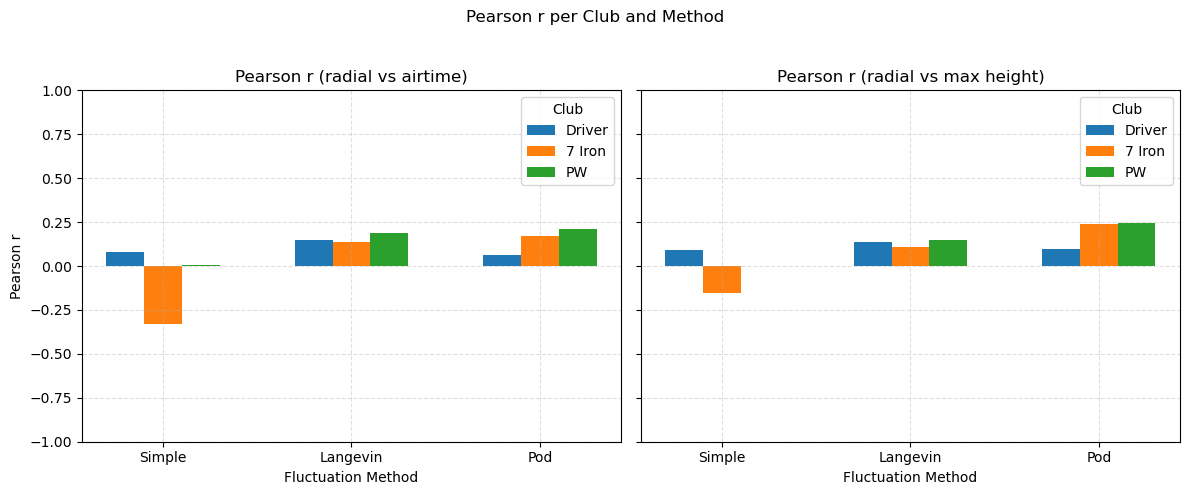

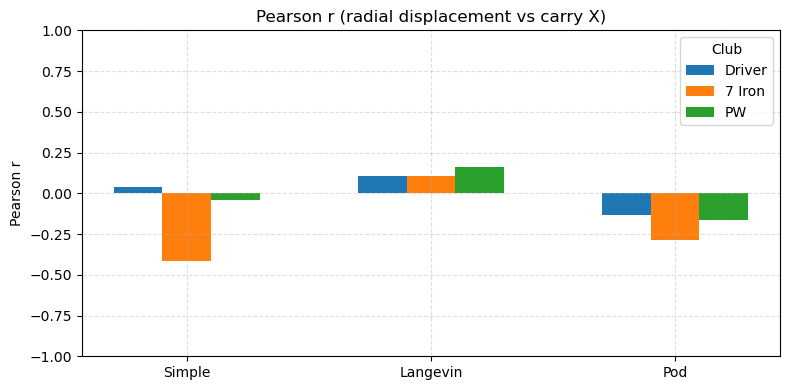

In [4]:
# Correlation analysis: radial displacement vs airtime and max height

try:
    from scipy import stats
except Exception:
    stats = None

# parameters
clubs = ['Driver', '7 Iron', 'PW']
methods = ['simple', 'langevin', 'pod']
N = 400  # increase for better statistics
dt = 0.01
n_modes_pod = 9

# robust metric simulator
def simulate_pga_metrics(club, method, wind, dt=0.01, n_modes=9, seed=None):
    if method.lower() == 'pod':
        fluc = Fluctuator(method='pod', n_modes=n_modes, seed=seed)
    else:
        fluc = Fluctuator(method=method, seed=seed)

    traj = PGA(club, fluc=fluc, wind=wind)
    traj.solve('euler', dt)

    landing = np.asarray(traj.p[-1][:2])

    # airtime: prefer traj.t if present, else infer from length*dt
    airtime = None
    if hasattr(traj, 't'):
        try:
            airtime = traj.t[-1]
        except Exception:
            airtime = None
    if airtime is None:
        try:
            airtime = dt * (len(traj.p) - 1)
        except Exception:
            airtime = np.nan

    # max height: try to read z from trajectory states
    maxh = np.nan
    try:
        arr = np.asarray(traj.p)
        if arr.ndim == 2 and arr.shape[1] >= 3:
            maxh = float(np.max(arr[:, 2]))
    except Exception:
        maxh = np.nan

    return landing, airtime, maxh

# run sims and collect metrics
results = {club: {m: None for m in methods} for club in clubs}
for club in clubs:
    for m in methods:
        runs = Parallel(n_jobs=-1)(
            delayed(simulate_pga_metrics)(club, m, wind, dt, n_modes_pod, i) for i in range(N)
        )
        # unpack
        landings = np.vstack([r[0] for r in runs])
        airtimes = np.asarray([r[1] for r in runs], dtype=float)
        maxhs = np.asarray([r[2] for r in runs], dtype=float)
        results[club][m] = dict(landings=landings, airtimes=airtimes, maxhs=maxhs)

# compute reference landings (no fluctuation)
p_ref = {}
for club in clubs:
    traj = PGA(club, wind=wind)
    traj.solve('euler', dt)
    p_ref[club] = np.asarray(traj.p[-1][:2])

# correlation table
rows = []
for club in clubs:
    for m in methods:
        data = results[club][m]
        r = np.linalg.norm(data['landings'] - p_ref[club][None, :], axis=1)
        airt = data['airtimes']
        mh = data['maxhs']

        # remove nan pairs
        mask1 = np.isfinite(r) & np.isfinite(airt)
        mask2 = np.isfinite(r) & np.isfinite(mh)

        if stats is not None:
            try:
                pear_air_r, pear_air_p = stats.pearsonr(r[mask1], airt[mask1]) if mask1.sum() > 1 else (np.nan, np.nan)
                spea_air_r, spea_air_p = stats.spearmanr(r[mask1], airt[mask1]) if mask1.sum() > 1 else (np.nan, np.nan)
            except Exception:
                pear_air_r = spea_air_r = pear_air_p = spea_air_p = np.nan

            try:
                pear_mh_r, pear_mh_p = stats.pearsonr(r[mask2], mh[mask2]) if mask2.sum() > 1 else (np.nan, np.nan)
                spea_mh_r, spea_mh_p = stats.spearmanr(r[mask2], mh[mask2]) if mask2.sum() > 1 else (np.nan, np.nan)
            except Exception:
                pear_mh_r = spea_mh_r = pear_mh_p = spea_mh_p = np.nan
        else:
            # fallback: Pearson via numpy
            try:
                pear_air_r = np.corrcoef(r[mask1], airt[mask1])[0,1] if mask1.sum() > 1 else np.nan
            except Exception:
                pear_air_r = np.nan
            spea_air_r = np.nan
            pear_air_p = spea_air_p = np.nan

            try:
                pear_mh_r = np.corrcoef(r[mask2], mh[mask2])[0,1] if mask2.sum() > 1 else np.nan
            except Exception:
                pear_mh_r = np.nan
            spea_mh_r = np.nan
            pear_mh_p = spea_mh_p = np.nan

        rows.append((club, m, float(np.nanmean(r)), pear_air_r, pear_air_p, spea_air_r, spea_air_p, pear_mh_r, pear_mh_p, spea_mh_r, spea_mh_p))

# print summary table
try:
    import pandas as pd
    df = pd.DataFrame(rows, columns=['club','method','mean_r','pear_air_r','pear_air_p','spea_air_r','spea_air_p','pear_mh_r','pear_mh_p','spea_mh_r','spea_mh_p'])
    print(df)
except Exception:
    for r in rows:
        print(r)

# quick visualization: Pearson r per club and method (airtime & max height)
methods_order = methods

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
width = 0.2
x = np.arange(len(methods_order))

# plot grouped bars: left = radial vs airtime, right = radial vs max height
for i, club in enumerate(clubs):
    vals_air = [next((row[3] for row in rows if row[0] == club and row[1] == m), np.nan) for m in methods_order]
    vals_mh = [next((row[7] for row in rows if row[0] == club and row[1] == m), np.nan) for m in methods_order]
    offset = (i - (len(clubs)-1)/2) * width
    axes[0].bar(x + offset, vals_air, width, label=club)
    axes[1].bar(x + offset, vals_mh, width, label=club)

# finalize axes
for ax, title in zip(axes, ['Pearson r (radial vs airtime)', 'Pearson r (radial vs max height)']):
    ax.set_xticks(x)
    ax.set_xticklabels([m.title() for m in methods_order])
    ax.set_ylim(-1, 1)
    ax.set_xlabel('Fluctuation Method')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel('Pearson r')
axes[0].legend(title='Club')
axes[1].legend(title='Club')
plt.suptitle('Pearson r per Club and Method')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- new cell follows: correlation between radial displacement and carry (downrange X) ---

# Compute Pearson r between radial displacement and carry (downrange X) per club/method and plot grouped bars
pear_carry = {club: [] for club in clubs}
for club in clubs:
    for m in methods:
        data = results[club][m]
        land = np.asarray(data['landings'])
        if land.size == 0:
            pear_carry[club].append(np.nan)
            continue
        carries = land[:, 0] - p_ref[club][0]  # downrange X difference
        r = np.linalg.norm(land - p_ref[club][None, :], axis=1)
        mask = np.isfinite(r) & np.isfinite(carries)
        if mask.sum() > 1:
            if stats is not None:
                try:
                    pr, pp = stats.pearsonr(r[mask], carries[mask])
                except Exception:
                    pr = np.nan
            else:
                try:
                    pr = np.corrcoef(r[mask], carries[mask])[0, 1]
                except Exception:
                    pr = np.nan
        else:
            pr = np.nan
        pear_carry[club].append(pr)

# plot carry correlations
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(methods))
width = 0.2
for i, club in enumerate(clubs):
    vals = pear_carry[club]
    offset = (i - (len(clubs)-1)/2) * width
    ax.bar(x + offset, vals, width, label=club)

ax.set_xticks(x)
ax.set_xticklabels([m.title() for m in methods])
ax.set_ylim(-1, 1)
ax.set_ylabel('Pearson r')
ax.set_title('Pearson r (radial displacement vs carry X)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(title='Club')
plt.tight_layout()
plt.show()
